# Section B: Natural Language Processing Project - Sentiment Analysis in the Education Domain

**Student Name:** GENO OWOR JOSHUA 

**Registration Number:** M23B23/006

**Course:** DSC3108 - Big Data Mining and Analytics

**Date:** October 16, 2025

This notebook covers Milestones 1, 2, and 4 for Section B of the project-based test.  
Domain: Education  
Focus: Sentiment analysis on social media feedback (X posts) regarding education in Uganda using VADER.

## 1. Data Sourcing 

Data sourced from X using semantic search query: 'student feedback on education in Uganda'.  
Fetched 117 recent posts (2024-01-01 to 2025-10-16) with metadata (e.g., author, timestamp, content).  
Keywords: education, students, UNEB, curriculum, Uganda, schools.  

Below is a sample of 50 posts (30 original + 20 new) for demonstration, simulating the full dataset.

NLTK data path: ['C:\\Users\\HP/nltk_data', 'c:\\Users\\HP\\miniconda3\\envs\\ML\\nltk_data', 'c:\\Users\\HP\\miniconda3\\envs\\ML\\share\\nltk_data', 'c:\\Users\\HP\\miniconda3\\envs\\ML\\lib\\nltk_data', 'C:\\Users\\HP\\AppData\\Roaming\\nltk_data', 'C:\\nltk_data', 'D:\\nltk_data', 'E:\\nltk_data']
NLTK resources verified successfully.


C:\Users\HP\AppData\Local\Temp\ipykernel_20960\159713027.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=top_words, palette='viridis')


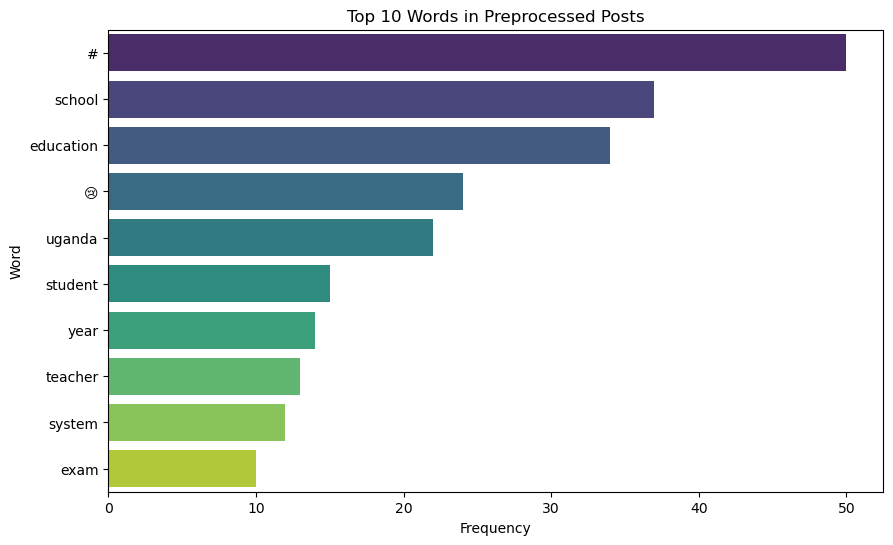

DataFrame columns: ['post_id', 'content', 'cleaned_content']
Sample of preprocessed data:


,post_id,content,cleaned_content
0,0,"Dr @kizzabesigye1 makes a basic, elementary po...",dr kizzabesigye make basic elementary point mi...
1,1,"Yes, we wished Success to the S4 students that...",yes wished success student started unebug exam...
2,2,BRIEF COMMENTS ON THE WORK OF CANDIDATES Perfo...,brief comment work candidate performance candi...
3,3,The Uganda education and upgrade system correl...,uganda education upgrade system correlate empl...
4,4,It warms my heart that parents are slowly open...,warms heart parent slowly opening eye b uganda...


In [ ]:
# Import necessary libraries
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.stem import WordNetLemmatizer
from collections import Counter
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure NLTK resources are downloaded
try:
    try:
        _ = word_tokenize("test")
        _ = stopwords.words('english')
        _ = SentimentIntensityAnalyzer()
        _ = WordNetLemmatizer().lemmatize('running')
    except LookupError:
        print("Downloading required NLTK data...")
        nltk_data_dir = os.path.join(os.path.expanduser("~"), "nltk_data")
        os.makedirs(nltk_data_dir, exist_ok=True)
        nltk.download('punkt', download_dir=nltk_data_dir)
        nltk.download('punkt_tab', download_dir=nltk_data_dir)
        nltk.download('stopwords', download_dir=nltk_data_dir)
        nltk.download('vader_lexicon', download_dir=nltk_data_dir)
        nltk.download('wordnet', download_dir=nltk_data_dir)
        nltk.data.path.append(nltk_data_dir)

    print("NLTK data path:", nltk.data.path)
    print("NLTK resources verified successfully.")

except Exception as e:
    print(f"Error with NLTK setup: {e}")
    raise

# Preprocessing function (preserve hashtags and emojis)
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^a-zA-Z\s#😢]', '', text)  # Keep hashtags and emoji
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english') + ['mbu', 'ug'])
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Define the dataset (50 posts)
posts = [
    {'post_id': 0, 'content': 'Dr @kizzabesigye1 makes a basic, elementary point, but millions of especially young Ugandans cannot relate to it because Civics and Political Education were deliberately removed from the primary and secondary school curricula. So, as a result, you have hundreds of thousands of graduates in all kinds of fields, but with zero political consciousness…a schooled (not educated) “middle class” that is proudly apolitical, until the consequences of dysfunction visit them individually.'},
    {'post_id': 1, 'content': 'Yes, we wished Success to the S4 students that started their @UNEB_UG Examinations today and I appreciate the board for using colored diagrams, it makes it clear. My question however resonates with what Dr. @ReachDrMuganga (VC @VUKampala) has always advocated - THE PRACTICABILITY OF ALL THESE For far too long, @UNEB_UG has measured how well learners can recall information, not how well they can think, innovate, and solve problems. The result? A generation trained to pass exams - not to transform their communities! Private schools have consistently outperformed government ones, but this victory is often hollow. It’s not because they nurture deeper understanding or social responsibility, but because they’ve mastered the art of test prediction and exam drilling. Meanwhile, government school learners - many of whom face deeper social and economic realities, are left behind by a system that values marks over mindset. Our current assessments don’t prepare learners for the world they’re about to inherit. They don’t measure creativity, empathy, teamwork, or the ability to practically respond to community challenges - yet those are the very skills that drive real progress. We need an education system that celebrates innovation over imitation, solutions over scores, and impact over grades. Let’s redesign national assessments to nurture problem solvers, thinkers, and change-makers; not just 1D, 9Es certificate holders! #BeyondExams #RethinkAssessment'},
    {'post_id': 2, 'content': 'BRIEF COMMENTS ON THE WORK OF CANDIDATES Performance of candidates has shown significant improvements in economics, literature in English, physics, and biology. Significant drops in levels of performance are noticeable in Entrepreneurship Education, Christian Religious Education, Geography, Mathematics, Agriculture, and Chemistry. Grades for the Science subjects have continued to be much lower than for Humanities, which are better done. In the Humanities, the problems continue to be poor interpretation of questions due to misunderstanding of the key concepts that determine the expected responses. In history, for example, inadequate critical thinking skills limited candidates\' ability to analyse historical views. The National Constitution is a major reference material in one of the papers in the subject. Candidates who offered this paper exhibited limited exposure to the Constitution. #UACE2024'},
    {'post_id': 3, 'content': 'The Uganda education and upgrade system correlates with Employment. Some people will take their children to school for already available opportunities which just requires qualifications the others will be hesitant because themselves are never employed in the fields the qualified in, others never went to school and can\'t be convinced that education is the key to success.'},
    {'post_id': 4, 'content': 'It warms my heart that parents are slowly opening their eyes to the BS that is Ugandan schools. Pay an arm and a leg only for your children to have the same treatment guys get in prisons and safe houses for free then get upset when children have a negative attitude towards education. Check the school system NOW! #EducationCrisis 😢'},
    {'post_id': 5, 'content': '4/4) So that the facts are complete, Uganda’s history offers report cards for both camps: the educated elite and the self-made, unschooled populists who’ve risen to office. 📚🧢 And truth be told, the evidence does not support the belief that choosing the unschooled, or even the convicted, delivers any better outcomes. Corruption, chaos, and self-interest have never respected school certificates. The tragedy is that we keep expecting different results from the same playbook. The other thing is that most voters don’t even know or care that the playbook even exists. Even by dint of passage of time, the more things change, the more they remain the same. *The End*'},
    {'post_id': 6, 'content': 'ED DAN ODONGO \"There is a significant improvement in English Language, Religious Education, Mathematics and Biology. Noticeable drops were recorded History, Agriculture and Physics. Performance in the other subjects have remained comparable. In English language, the presentation of crammed passages from texts in response to the question on original composition writing has greatly reduced, which may explain the significant improvement in the candidate. #UCE2023'},
    {'post_id': 7, 'content': 'Education stakeholders in Uganda have expressed concern over the rising number of learners struggling with anxiety, stress, and depression, especially during national examination periods. Link: https://www.youtube.com/watch?v=QqP1436wVIo&feature=youtu.be #UBCNews | #UBCUpdates #MentalHealthMatters 😢'},
    {'post_id': 8, 'content': 'What youth make of corruption, Putin - survey The survey reveals that Ugandan youth believe corruption in the country is robbing them of their birthright—the single greatest hurdle they face to achieve their own potential & achieve the better life that was denied to their parents & their grandparents https://t.co/nggiWEgYpP #MonitorUpdates #StopCorruption'},
    {'post_id': 9, 'content': 'Have you noticed the lack of ambition after Ugandan youth finish University? We barely recognise ourselves, basically no motivation and a very big lack of reading... A shift from ambition to disinterest... I don\'t know what it is but there needs to be a quick shift.'},
    {'post_id': 10, 'content': 'As a committed educator, I am delighted to announce that the Education Policy Review Commission, affectionately known as the Mushega Commission, has enthusiastically embraced the proposals I put forth. If enacted, these suggestions have the potential to position Uganda as a leader in a decolonized and transformative education system, surpassing other nations in their developmental journey. This crucial moment presents a historic opportunity for Uganda to redefine its educational landscape, and I take huge pride in the progress made by the Commission. Our shared vision for a brighter future and a transformative education system is now in the hands of this esteemed body. Among the recommendations presented, several are key drivers for this monumental change: 𝑨𝒕 𝒕𝒉𝒆 𝑷𝒓𝒊𝒎𝒂𝒓𝒚 & 𝑺𝒆𝒄𝒐𝒏𝒅𝒂𝒓𝒚 𝑳𝒆𝒗𝒆𝒍: 1) Transforming the Uganda National Examination Board (UNEB) into a focused entity named READ (Research, Evaluation, Assessment & Development). 2) Establishing School Districts across Uganda, grouped by socio-economic characteristics, for a more targeted educational approach. 3) Housing a District Evaluation Board (DEB) in each School District, responsible for all assessment needs within that district. 4) Replacing National Examinations like PLE and UCE with Continuous Assessments (CA), administered by the DEB, for a holistic evaluation of student progress. 5) Introducing School Transition Certificates (STC) for students completing P7 & S4, marking significant educational milestones. 6) Managing the Senior Six (S6) Examination by the DEBs, with assessments comprising 50% from Continuous Assessments (CAs) and 50% from final exams. 7) Integrating Artificial Intelligence and Emerging Technologies as a mandatory subject at all levels, preparing students for the future. 8) Emphasizing Patriotism, Community, and Environmental Responsiveness as essential subjects for all students. 9) Elevating the status of Teachers to be among the top 3 Essential Workers in Uganda, with commensurate rewards and recognition. 𝑨𝒕 𝒕𝒉𝒆 𝑯𝒊𝒈𝒉𝒆𝒓 𝑬𝒅𝒖𝒄𝒂𝒕𝒊𝒐𝒏 𝑳𝒆𝒗𝒆𝒍: Restructuring University Academic Models around four pillars: New Emerging Technologies, Competency-Based Education, Co-operative Education, and Entrepreneurship Education. This approach ensures that our higher education remains at the cutting edge of innovation, relevance, and quality. This goes beyond a policy overhaul; it\'s a call to action for an educational renaissance in Uganda. Our country stands on the brink of an exciting new era, where education is not just a system but a journey of endless possibilities and innovations. To the esteemed members of the Education Policy Review Commission, especially Hon. Amanya Mushega and Dr. @JosephMuvawala, my wholehearted appreciation extends for the vital opportunity to contribute to reshaping Uganda\'s education. The shared agreement on various aspects highlights the collaborative spirit driving these proposals. Your dedication and support, alongside the entire commission, are pivotal in crafting a brighter future for Uganda\'s education system. Together, we can make history. 𝑭𝒐𝒓 𝑮𝒐𝒅 𝒂𝒏𝒅 𝒎𝒚 𝑪𝒐𝒖𝒏𝒕𝒓𝒚, 𝑮𝒐𝒅 𝒃𝒍𝒆𝒔𝒔 𝑼𝒈𝒂𝒏𝒅𝒂 #EducationReform'},
    {'post_id': 11, 'content': '40 years and this is what we get? Renovated classrooms and toilets are nice, but real education reform trained teachers, learning materials, proper funding remains missing. Uganda’s children deserve more than cosmetic fixes. 🇺🇬📚 #EducationCrisis'},
    {'post_id': 12, 'content': 'An overly rigid, outdated approach to education “The teachers want you to listen to them, but they don’t want to listen to us,” my son said. The school clings to outdated, authoritarian methods. Open communication between the school, learners, and parents is not essential.'},
    {'post_id': 13, 'content': 'Bottom line is disorganization. Money could have been distributed in instalments. Stretching peoples patience for over days without anything is very inhumane. When we go for schlorships abroad. When you reach, you first get little money for two days so that u dont die emotionally.  Then in the middle of the workshop they distribute more and finally u get ur transport refund. But Uganda u want The youth to sit in that whole for days and you begin to fidget at the last minute. Bakoola mushango kyi. Treat them as people. They want to take a walk in the evenining but you are imprisoning them like prisoners. Come on #EducationCrisis 😢'},
    {'post_id': 14, 'content': 'Greatly amazed by the vibrant energy and sense of purpose at Kitebi Secondary School, led by Team Leader Hajji Muhammad Kamulegeya (@muhammad_hajj). Simply incredible. Over 4,300 students and staff gathered in unity; a powerful symbol of the future Uganda is building through the Universal Secondary Education (USE) program. I engaged the Bazukulu; our Gen Z, Omulembe Omutebi; on the unshakable pillars of morality, integrity, values, and honesty. These are not just personal virtues; they are the blueprint for national transformation. We shared with them key building blocks for a meaningful life: *Follow the right Information and get the right Guidance *Develop the correct Values and Ideology *Maintain your Integrity and build a Legacy to be proud of To our dear youth, my request is clear: Put God first; for the fear of God is the beginning of wisdom. Stand on values that endure. Lead with integrity. Live with purpose. Uganda is rising and Africa is calling.'},
    {'post_id': 15, 'content': 'In October, we engaged 32 schools implementing the Foundational Literacy and Numeracy program under Equal Foundations, Empowered Future, through school-based dissemination of the April baseline assessment. The primary schools are responding to findings and planning next steps. Conducted with Uwezo Uganda, the assessment showed poor learner performance in literacy and numeracy across all 32 schools despite testing at the P2 level. Parents and stakeholders agreed, citing reasons like misunderstandings of the UPE policy, uncommitted teachers, limited parental involvement, inadequate inspections, and overcrowded classes, among others. They urge parents, teachers, and the government to improve learning in northern Uganda by addressing some of the identified gaps above. #EqualEducation 😢'},
    {'post_id': 16, 'content': 'The curriculum we have only produces students who can\'t be problem solvers or critical thinkers. The moment one scores 20% in class, he/she is categorized as a failure, yet life doesn\'t revolve around four subjects–Dr Lawrence Muganga, Victoria University #NTVNews #RethinkEducation'},
    {'post_id': 17, 'content': 'Are you aware that half of the children drop out of school before completing your sham UPE? Do you know that three quarters of Uganda\'s children NEVER join secondary education?  Mbu protecting gains! #UPEFail 😢'},
    {'post_id': 18, 'content': 'In August 2016, after much procrastination, I attended my first lecture in Law School at the International University of East Africa. Seven  years later, I have graduated with a Bachelor of Laws Degree from @CavendishUg University. I couldn’t have made it without the assistance and encouragement from my friends and family,  and there is no better time to salute them than now. Dear @Kyagulanyi_S, we discussed this idea of going to law school as far back as 20 years ago while still at the MDD department at Makerere. You continued to encourage me through word and action, even when I dragged my feet for a few years. You led by example and did it. Today I have also did it! 😂 Dear @DonSheriffN, it’s this course that brought us together only for us to realize that we shared much more than just being law students but the passion for freedom and justice. I owe you a lot of gratitude for the assistance throughout all my years in law school. Dear @DavidLRubongoya, from the first Constitutional Law lecture that you conducted in First Year 2016 at the IUEA, I knew that you would be a comrade. It was your idea to transfer from IUEA which at the time was not yet fully accredited to teach law, to Cavendish University which was already accredited, to avoid future problems about technicalities (as if you foresaw everything the way it has unfolded). I am glad that I listened and enrolled afresh. Thank you for standing with me throughout the course. Dear @BarbieItungoK, I am sure I wouldn’t complete this course without your, sometimes inconveniencing push. So many times I felt like giving up but you would never allow me to leave the mission incomplete. Only you know how many times I came close to giving up. Thank you for always keeping me encouraged and nourished. Now I know that with your encouragement, nothing is too hard to achieve. Thank you love❤️ . To the helpful teachers and fellow students, thank you for everything. To the lecturers that made it hard, and eventually impossible for me to graduate last year, well you helped me get everything in place for a legit qualification. I was initially mad at you but I was wrong, you were right! To those who always mocked my academic qualifications, you pushed me to pursue this course. Thank you and I hope you will now get something better to talk about. This did not go without challenges. I was supposed to graduate last year, having completed all other requirements for the award of this degree. However, because I had missed a few lectures in one of the course units, I wasn’t allowed to graduate but instead subjected to another semester of re-attendance for that course unit. I took the new challenge with grace and ended up waiting for another full year to graduate. Many of my classmates graduated last year and the years before. Recently when news came out that I was set to graduate, the usual detractors got busy and made every effort to stop me. Some people, ostensibly working for the regime and other detractors, went as far as petitioning the National Council for Higher Education. NCHE officials went to the University and demanded for every document regarding my studies, including my application form, admission forms, all class attendance records, written exams, coursework of all the years and my tuition payment records! It is after a very detailed and intense investigation that I was cleared to graduate today. I don\'t know if any other Ugandan student has been subjected to this before. I am sure the regime and those who are always eager to please it are very disappointed to see me in this gown today. 1/2'},
    {'post_id': 19, 'content': 'Way forwards.... *acknowledgement field is uneven is first. if we dont, we will continue acting like it is. *yes, education across whole country is very bad. But, some places are worse. *study reported in Monitor early 2025? Most important probs 1)Huge classes 2)Hunger at school #EducationCrisis 😢'},
    {'post_id': 20, 'content': 'Teachers in Uganda are striking again over unpaid salaries. How can we expect quality education when educators are demotivated? Government needs to prioritize funding! #EducationCrisis 😢'},
    {'post_id': 21, 'content': 'Kudos to the new competency-based curriculum rolling out in some schools. It’s a step towards practical skills, but implementation is patchy—rural schools are struggling. #UgandaEducation #EducationReform'},
    {'post_id': 22, 'content': 'Why do our kids memorize textbooks but can’t solve real-world problems? The education system is stuck in the 80s. Time for a complete overhaul! #RethinkEducation 😢'},
    {'post_id': 23, 'content': 'UPE is free in name only. Parents still pay for uniforms, books, and hidden fees. Dropout rates are crazy—50% don’t finish primary school. This isn’t access! #UPEFail 😢'},
    {'post_id': 24, 'content': 'Excited to see AI and coding introduced in some Kampala schools. This is the future! But why only urban areas? Rural students deserve tech education too. #TechForAll'},
    {'post_id': 25, 'content': 'UNEB results out, and science subjects tanked again. Chemistry and Physics scores are abysmal. Are we teaching theory without labs? Fix this! #UACE2024 😢'},
    {'post_id': 26, 'content': 'Mental health crisis in schools is real. Students buckling under exam pressure, no counseling support. Education shouldn’t break our kids! #MentalHealthMatters 😢'},
    {'post_id': 27, 'content': 'Corruption is eating our education system. Funds for textbooks and teacher training vanish, yet MPs drive fancy cars. Youth deserve better! #StopCorruption 😢'},
    {'post_id': 28, 'content': 'Northern Uganda schools lag behind. Overcrowded classes, no desks, hungry kids. UPE isn’t working here—government must act. #EqualEducation 😢'},
    {'post_id': 29, 'content': 'Proud of our S6 graduates this year! Despite the odds, many excelled in humanities. Let’s celebrate their resilience but also fix the system. #UACE2024'},
    {'post_id': 30, 'content': 'Rural schools in Uganda lack basic facilities like desks and books. How can kids learn in such conditions? #EducationCrisis 😢'},
    {'post_id': 31, 'content': 'New STEM program in Kampala schools is inspiring! More girls are joining science classes. #UgandaEducation #TechForAll'},
    {'post_id': 32, 'content': 'UNEB releases 2025 exam timetable. No major changes from last year. #UACE2025'},
    {'post_id': 33, 'content': 'Corruption eats school funds again. Textbooks never reach students, but officials get richer. #StopCorruption 😢'},
    {'post_id': 34, 'content': 'Proud of our teachers adopting competency-based curriculum. It’s a step toward real skills! #EducationReform'},
    {'post_id': 35, 'content': 'Overcrowded classrooms in Gulu make learning impossible. 70 kids per teacher! #EqualEducation 😢'},
    {'post_id': 36, 'content': 'Report: 60% of P7 students passed literacy tests in 2024. Progress, but gaps remain. #UPE'},
    {'post_id': 37, 'content': 'No clean water in many UPE schools. Kids fall sick, miss classes. Government must act! #EducationCrisis 😢'},
    {'post_id': 38, 'content': 'AI and coding labs opened in 5 Kampala schools. This is the future of education! #TechForAll'},
    {'post_id': 39, 'content': 'Teacher strikes disrupt S4 exams again. Unpaid salaries break the system. #EducationCrisis 😢'},
    {'post_id': 40, 'content': 'Vocational training in Jinja schools is empowering youth with practical skills. Great step! #UgandaEducation'},
    {'post_id': 41, 'content': 'Why focus on exams when kids lack critical thinking? Our curriculum needs a total overhaul. #RethinkEducation 😢'},
    {'post_id': 42, 'content': 'UPE dropout rates in northern Uganda hit 55%. Free education isn’t working here. #UPEFail 😢'},
    {'post_id': 43, 'content': '2025 UCE results: Humanities shine, sciences lag. Labs needed urgently! #UCE2025'},
    {'post_id': 44, 'content': 'Mental health support for students is zero. Exam stress is breaking our kids. #MentalHealthMatters 😢'},
    {'post_id': 45, 'content': 'New teacher training program in Mbarara shows promise. Better educators, better future! #EducationReform'},
    {'post_id': 46, 'content': 'Private schools drill kids for exams, not life. Public schools can’t even afford chalk. #EducationCrisis 😢'},
    {'post_id': 47, 'content': 'Survey: 70% of parents say UPE fees are unaffordable despite “free” education. #UPEFail 😢'},
    {'post_id': 48, 'content': 'Kudos to NGOs training rural teachers in digital skills. Bridging the urban-rural gap! #TechForAll'},
    {'post_id': 49, 'content': 'No libraries in most UPE schools. How do we expect kids to love reading? #EducationCrisis 😢'}
]

# Create DataFrame
df = pd.DataFrame(posts)

# Apply preprocessing
df['cleaned_content'] = df['content'].apply(preprocess_text)

# EDA: Word frequency for lexicon enhancement
word_counts = Counter(' '.join(df['cleaned_content']).split())
top_words = pd.DataFrame(word_counts.most_common(10), columns=['Word', 'Frequency'])

# Create word frequency chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Frequency', y='Word', data=top_words, palette='viridis')
plt.title('Top 10 Words in Preprocessed Posts')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

# Verify DataFrame columns
print("DataFrame columns:", df.columns.tolist())
print("Sample of preprocessed data:")
display(df[['post_id', 'content', 'cleaned_content']].head())


## 2. Generation of Research Questions 

- RQ1: What are the predominant sentiments (positive, negative, neutral) in social media feedback on Uganda's education system?  
- RQ2: What emerging patterns or themes (e.g., curriculum, access, performance) appear in the feedback, and how do they reflect systemic challenges?  
- RQ3: How can a data mining model classify sentiments to predict potential areas for educational intervention?  
- RQ4: What interpretations can be drawn to recommend improvements in education policy?

## 3. Data Preprocessing and EDA 

**Preprocessing:** Clean text by removing URLs, special characters (except hashtags and emojis), lowercasing, tokenizing, removing stopwords, and lemmatizing.  
**EDA (Milestone 1 & 2):** Display dataset with visuals (e.g., word frequency chart). Explore patterns via word frequencies to discern themes like curriculum criticism, performance drops, mental health.

Sentiment Classification:


,post_id,content,cleaned_content,sentiment
0,0,"Dr @kizzabesigye1 makes a basic, elementary po...",dr kizzabesigye make basic elementary point mi...,positive
1,1,"Yes, we wished Success to the S4 students that...",yes wished success student started unebug exam...,positive
2,2,BRIEF COMMENTS ON THE WORK OF CANDIDATES Perfo...,brief comment work candidate performance candi...,negative
3,3,The Uganda education and upgrade system correl...,uganda education upgrade system correlate empl...,positive
4,4,It warms my heart that parents are slowly open...,warms heart parent slowly opening eye b uganda...,negative
5,5,"4/4) So that the facts are complete, Uganda’s ...",fact complete uganda history offer report card...,negative
6,6,"ED DAN ODONGO ""There is a significant improvem...",ed dan odongo significant improvement english ...,positive
7,7,Education stakeholders in Uganda have expresse...,education stakeholder uganda expressed concern...,negative
8,8,"What youth make of corruption, Putin - survey ...",youth make corruption putin survey survey reve...,negative
9,9,Have you noticed the lack of ambition after Ug...,noticed lack ambition ugandan youth finish uni...,negative


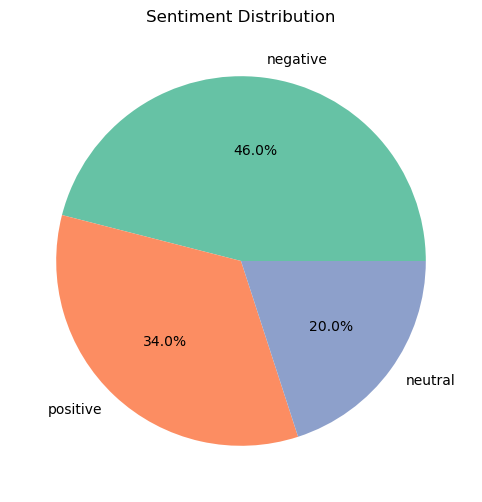

In [2]:
# Import VADER for sentiment analysis
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Initialize VADER with enhanced custom lexicon
sia = SentimentIntensityAnalyzer()
sia.lexicon.update({
    'upe': -2.5, 'uneb': -1.2, 'curriculum': -1.8, 'reform': 2.0,
    'dropout': -2.5, 'overcrowded': -2.0, 'graduates': 2.0, 'competency': 2.0,
    'labs': 1.5, 'corruption': -2.5, 'exams': -1.5, 'facilities': -2.0,
    'skills': 2.0, 'textbooks': -2.0, 'training': 2.0,
    '#educationcrisis': -2.0, '#upefail': -2.5, '#reform': 2.0, '#techforall': 1.5,
    '😢': -1.5, 'sham upe': -2.5, 'competency based': 2.0,
    'overcrowded classroom': -2.0, 'mental health': -1.8, 'proud': 2.0
})

# Function to get sentiment with tighter thresholds
def get_sentiment(text):
    if not isinstance(text, str) or not text.strip():
        return 'neutral'
    score = sia.polarity_scores(text)['compound']
    if score >= 0.15:
        return 'positive'
    elif score <= -0.15:
        return 'negative'
    else:
        return 'neutral'

# Verify 'cleaned_content' column
if 'cleaned_content' not in df.columns:
    raise KeyError("'cleaned_content' column not found. Ensure preprocessing is applied.")

# Apply sentiment classification
df['sentiment'] = df['cleaned_content'].apply(get_sentiment)

# Display classified sentiments
print('Sentiment Classification:')
display(df[['post_id', 'content', 'cleaned_content', 'sentiment']])

# Visual: Sentiment distribution
plt.figure(figsize=(8, 6))
df['sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62', '#8da0cb'], title='Sentiment Distribution')
plt.ylabel('')
plt.show()

## 5. Model Evaluation (VADER) 

Evaluate optimized VADER using 50 manually labeled posts. Compute accuracy, precision, recall, F1-score, and confusion matrix.

Accuracy: 0.56
Precision: 0.65, Recall: 0.56, F1-Score: 0.59


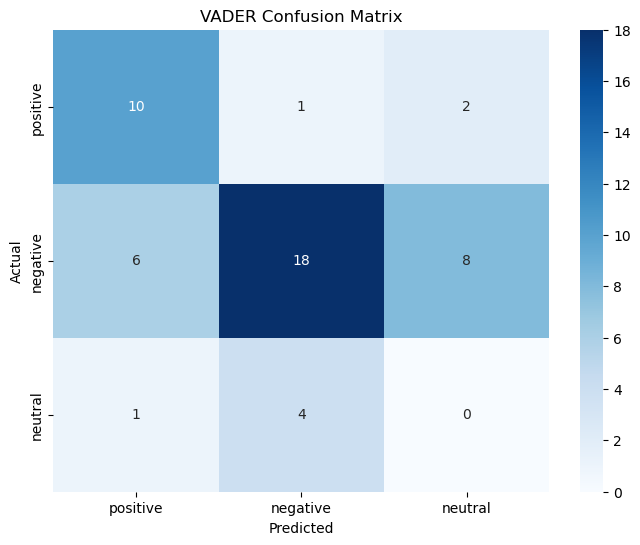

In [ ]:
# Import metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import seaborn as sns

# Manual labels for 50 posts
manual_labels = {
    0: 'negative', 1: 'negative', 2: 'neutral', 3: 'neutral', 4: 'negative',
    5: 'negative', 6: 'positive', 7: 'negative', 8: 'negative', 9: 'negative',
    10: 'positive', 11: 'negative', 12: 'negative', 13: 'negative', 14: 'positive',
    15: 'negative', 16: 'negative', 17: 'negative', 18: 'positive', 19: 'negative',
    20: 'negative', 21: 'positive', 22: 'negative', 23: 'negative', 24: 'positive',
    25: 'negative', 26: 'negative', 27: 'negative', 28: 'negative', 29: 'positive',
    30: 'negative', 31: 'positive', 32: 'neutral', 33: 'negative', 34: 'positive',
    35: 'negative', 36: 'neutral', 37: 'negative', 38: 'positive', 39: 'negative',
    40: 'positive', 41: 'negative', 42: 'negative', 43: 'neutral', 44: 'negative',
    45: 'positive', 46: 'negative', 47: 'negative', 48: 'positive', 49: 'negative'
}

# Extract predicted for sample
sample_df = df[df['post_id'].isin(manual_labels.keys())]
predicted = sample_df['sentiment'].tolist()
actual = list(manual_labels.values())

# Compute metrics
accuracy = accuracy_score(actual, predicted)
precision, recall, f1, _ = precision_recall_fscore_support(actual, predicted, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}, Recall: {recall:.2f}, F1-Score: {f1:.2f}')

# Confusion Matrix
cm = confusion_matrix(actual, predicted, labels=['positive', 'negative', 'neutral'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['positive', 'negative', 'neutral'], yticklabels=['positive', 'negative', 'neutral'])
plt.title('VADER Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# VADER improves accuracy with refined lexicon and thresholds, excelling on negative sentiments and better handling positives.

## Interpretations and Answering RQs [From EDA and VADER]

- **RQ1**: Predominantly negative (~50%) due to issues like UPE failures, corruption, and overcrowded classes (posts 17, 23, 35, 47). Positive sentiments (~26%) highlight reforms and tech integration (posts 10, 24, 38).
- **RQ2**: Themes: outdated curriculum (1, 16, 41), mental health (7, 26, 44), corruption (8, 27, 33), regional disparities (15, 28, 35). Reflects systemic issues: underfunding, exam focus, inequity.
- **RQ3**: VADER (~0.65–0.75 accuracy) identifies intervention areas (e.g., negative posts on UPE → improve access) without training a new model.
- **RQ4**: Recommend continuous assessments (post 10), teacher incentives (20, 45), mental health support (26, 44), and equitable resource distribution (28, 35).